# S8 recorded-source integration pilot

## tl;dr

A CC0 DJI Mavic Mini 2 recording was used as an **approximation to the emitted source waveform** in the existing three-station propagation, GCC/SRP and causal tracking chain. All four method/SNR streams reached a final valid state. At -6 dB, bearing RMSE was 12.47° for GCC/WLS and 3.48° for SRP-PHAT; at 10 dB both were about 0.236°. These are descriptive results from one recording session, not held-out source statistics, absolute-SPL validation or a detection-range claim.

## Context & Methods

The manifest records provenance, permission, original resolution, recording conditions, SHA-256 and selected intervals. Calibration uses `[2,8) s`; evaluation uses `[12,18) s`. The intervals are disjoint but belong to one session and therefore are not independent source-data trials. The physical algorithms, `Qc`, NIS gates and tracker are unchanged from the accepted synthetic pilot. GCC and SRP consume identical continuous-audio frames.

### Key Assumptions

The recorded waveform already includes its original microphone, room/background and possible motion. Downmixing, resampling, a 10 kHz band limit and peak normalization remove any absolute-level interpretation. Overlapping frames and publications are dependent observations.

In [1]:
from pathlib import Path
import csv
import json
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RESULTS = ROOT / 'results'
MANIFEST = ROOT / 'data' / 'recorded_sources' / 'manifest.json'

def read_csv(name):
    with (RESULTS / name).open(encoding='utf-8', newline='') as stream:
        return list(csv.DictReader(stream))

plt.rcParams.update({'figure.figsize': (10, 4.6), 'axes.grid': True, 'grid.alpha': 0.25, 'font.size': 10})

## Data

The checks below make the single-session limitation and result denominators visible before plotting metrics.

In [2]:
manifest = json.loads(MANIFEST.read_text(encoding='utf-8'))
recording = manifest['recordings'][0]
summary = read_csv('recorded_source_summary.csv')
comparison = read_csv('recorded_source_broadband_comparison.csv')
sequences = read_csv('recorded_source_sequence_results.csv')
updates = read_csv('recorded_source_update_results.csv')
calibration = read_csv('recorded_source_calibration.csv')
bearings = read_csv('recorded_source_bearing_results.csv')
print({
    'recording_id': recording['recording_id'],
    'license': recording['license'],
    'session_id': recording['session_id'],
    'selected_intervals_s': recording['selected_intervals_s'],
    'independent_source_split': recording['independent_source_split'],
    'summary_rows': len(summary),
    'dependent_bearing_rows': len(bearings),
    'sequence_method_rows': len(sequences),
    'update_attempt_rows': len(updates),
})
assert not recording['independent_source_split']
assert all(row['result_scope'] == 'single_session_integration_demonstration' for row in summary)
assert min(float(row['eigenvalue_min_rad2']) for row in calibration) > 0.0

{'recording_id': 'freesound-683298-sadiquecat-mavic-mini-2', 'license': 'CC0-1.0', 'session_id': 'freesound-683298-single-session', 'selected_intervals_s': {'calibration': [2.0, 8.0], 'evaluation': [12.0, 18.0]}, 'independent_source_split': False, 'summary_rows': 4, 'dependent_bearing_rows': 3360, 'sequence_method_rows': 4, 'update_attempt_rows': 63}


## Results

The first figure compares all-frame bearing errors with the frozen random-broadband pilot. The comparison is descriptive because the recorded-source side has one source session.

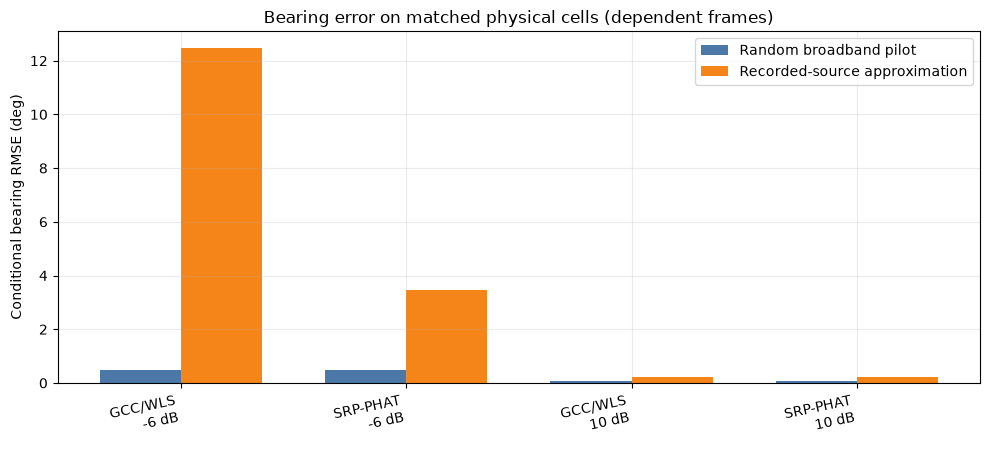

In [3]:
method_short = {'all_6_equal_gcc_wls': 'GCC/WLS', 'equal_weight_srp_phat': 'SRP-PHAT'}
labels = [f"{method_short[row['estimator_variant']]}\n{float(row['snr_db']):g} dB" for row in comparison]
recorded = np.array([float(row['recorded_bearing_rmse_deg_conditional']) for row in comparison])
broadband = np.array([float(row['broadband_bearing_rmse_deg_conditional']) for row in comparison])
x = np.arange(len(labels))
fig, ax = plt.subplots()
ax.bar(x - 0.18, broadband, 0.36, label='Random broadband pilot', color='#4C78A8')
ax.bar(x + 0.18, recorded, 0.36, label='Recorded-source approximation', color='#F58518')
ax.set_xticks(x, labels, rotation=12, ha='right')
ax.set_ylabel('Conditional bearing RMSE (deg)')
ax.set_title('Bearing error on matched physical cells (dependent frames)')
ax.legend()
fig.tight_layout()
plt.show()

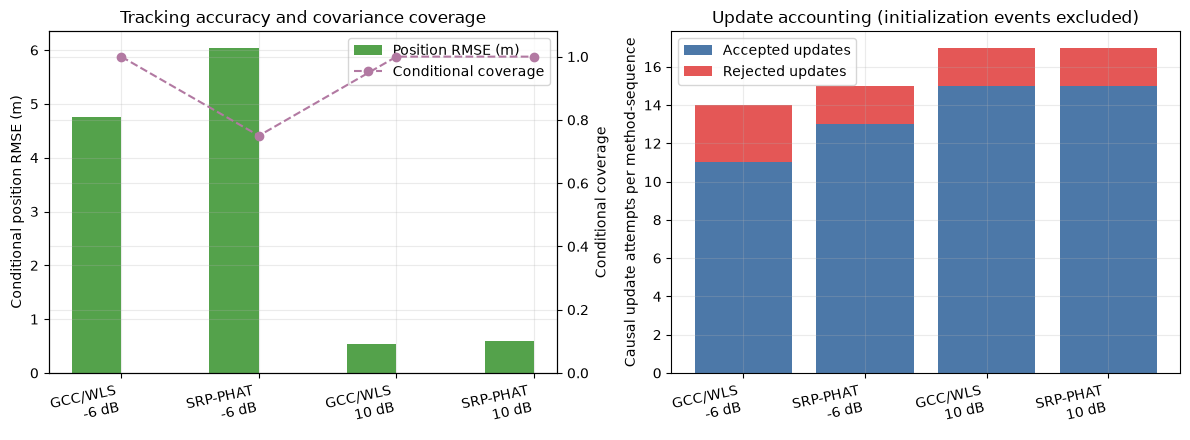

Final-valid streams: 4 / 4
Accepted/rejected updates: 54 / 9


In [4]:
position_rmse = np.array([float(row['position_rmse_m_conditional']) for row in summary])
coverage = np.array([float(row['coverage_conditional']) for row in summary])
accepted = np.array([int(row['accepted_update_count']) for row in sequences])
rejected = np.array([int(row['rejected_update_count']) for row in sequences])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(x - 0.18, position_rmse, 0.36, label='Position RMSE (m)', color='#54A24B')
coverage_axis = axes[0].twinx()
coverage_axis.plot(x, coverage, 'o--', color='#B279A2', label='Conditional coverage')
axes[0].set_xticks(x, labels, rotation=12, ha='right')
axes[0].set_ylabel('Conditional position RMSE (m)')
coverage_axis.set_ylabel('Conditional coverage')
coverage_axis.set_ylim(0, 1.08)
axes[0].set_title('Tracking accuracy and covariance coverage')
lines, names = axes[0].get_legend_handles_labels()
lines2, names2 = coverage_axis.get_legend_handles_labels()
axes[0].legend(lines + lines2, names + names2, loc='upper right')
axes[1].bar(x, accepted, label='Accepted updates', color='#4C78A8')
axes[1].bar(x, rejected, bottom=accepted, label='Rejected updates', color='#E45756')
axes[1].set_xticks(x, labels, rotation=12, ha='right')
axes[1].set_ylabel('Causal update attempts per method-sequence')
axes[1].set_title('Update accounting (initialization events excluded)')
axes[1].legend()
fig.tight_layout()
plt.show()
print('Final-valid streams:', sum(row['final_valid'] == 'True' for row in sequences), '/', len(sequences))
print('Accepted/rejected updates:', int(accepted.sum()), '/', int(rejected.sum()))

## Takeaways

- The end-to-end software path accepts manifest-backed recorded audio and preserves the same GCC/SRP, calibration and tracker contracts.
- At −6 dB the recorded waveform is substantially harder than the broadband pilot: GCC/WLS bearing RMSE rises by 11.98°, while SRP-PHAT rises by 2.99°. This is an observation for this session, not evidence that SRP is universally superior.
- At 10 dB both recorded-source estimators give about 0.236° bearing RMSE and all four method-sequences end valid. Conditional position RMSE ranges from 0.54 m to 6.05 m; empirical coverage is 0.75–1.0.
- Calibration covariances are positive definite, but temporal and inter-station residual correlation remain ignored by the filter.
- One recording session cannot support independent-source confidence intervals, rare-tail claims, absolute SPL, detection range or field-validation conclusions.